# 核心原因：计算图完整性
## 计算图的基础概念

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

def computation_graph_basics():
    """
    解释计算图的基本概念
    """
    print("=== 计算图基础 ===\n")
    
    # 创建叶节点（输入）
    x = torch.tensor([2.0], requires_grad=True)
    w = torch.tensor([3.0], requires_grad=True)
    b = torch.tensor([1.0], requires_grad=True)
    
    print("叶节点（Leaf Nodes）:")
    print(f"  x: {x.item()}, requires_grad={x.requires_grad}, is_leaf={x.is_leaf}")
    print(f"  w: {w.item()}, requires_grad={w.requires_grad}, is_leaf={w.is_leaf}")
    print(f"  b: {b.item()}, requires_grad={b.is_leaf}, is_leaf={b.is_leaf}")
    
    # 构建计算图
    y = w * x + b  # y = 3*2 + 1 = 7
    z = y ** 2     # z = 49
    
    print(f"\n计算图结构:")
    print(f"  y: {y.item()}, requires_grad={y.requires_grad}, is_leaf={y.is_leaf}")
    print(f"  z: {z.item()}, requires_grad={z.requires_grad}, is_leaf={z.is_leaf}")
    
    print(f"\n梯度函数链:")
    print(f"  z.grad_fn: {z.grad_fn}")  # PowBackward0
    print(f"  y.grad_fn: {y.grad_fn}")  # AddBackward0
    print(f"  (w*x).grad_fn: {(w*x).grad_fn}")  # MulBackward0

computation_graph_basics()

=== 计算图基础 ===

叶节点（Leaf Nodes）:
  x: 2.0, requires_grad=True, is_leaf=True
  w: 3.0, requires_grad=True, is_leaf=True
  b: 1.0, requires_grad=True, is_leaf=True

计算图结构:
  y: 7.0, requires_grad=True, is_leaf=False
  z: 49.0, requires_grad=True, is_leaf=False

梯度函数链:
  z.grad_fn: <PowBackward0 object at 0x2da739f90>
  y.grad_fn: <AddBackward0 object at 0x2da739f90>
  (w*x).grad_fn: <MulBackward0 object at 0x2da739f90>


## 叶节点修改如何破坏计算图

In [2]:
def leaf_modification_problem():
    """
    演示直接修改叶节点如何破坏计算图
    """
    print("=== 叶节点修改问题演示 ===\n")
    
    # 创建计算图
    x = torch.tensor([2.0], requires_grad=True)
    y = x ** 2  # y = 4
    
    print("原始计算图:")
    print(f"  x: {x.item()}, grad_fn={x.grad_fn}, is_leaf={x.is_leaf}")
    print(f"  y: {y.item()}, grad_fn={y.grad_fn}")
    
    # 尝试直接修改叶节点
    try:
        x[0] = 3.0  # ❌ 这会破坏计算图
        print(f"\n修改后 x: {x.item()}")
        
        # 计算梯度
        y.backward()
        print(f"梯度: {x.grad}")
    except RuntimeError as e:
        print(f"\n❌ 错误: {e}")
        print("\n问题:")
        print("  1. x 的值被修改，但计算图仍然记录的是旧值")
        print("  2. 梯度计算时会基于不一致的状态")
        print("  3. 导致梯度计算结果错误")

leaf_modification_problem()

=== 叶节点修改问题演示 ===

原始计算图:
  x: 2.0, grad_fn=None, is_leaf=True
  y: 4.0, grad_fn=<PowBackward0 object at 0x2d5a72f20>

❌ 错误: a view of a leaf Variable that requires grad is being used in an in-place operation.

问题:
  1. x 的值被修改，但计算图仍然记录的是旧值
  2. 梯度计算时会基于不一致的状态
  3. 导致梯度计算结果错误


# 深层原因分析
## 自动微分（Autograd）的依赖追踪

In [3]:
def autograd_dependency_tracking():
    """
    解释Autograd如何追踪依赖关系
    """
    print("=== Autograd 依赖追踪 ===\n")
    
    # 创建计算图
    a = torch.tensor([2.0], requires_grad=True)
    b = a ** 2
    c = b + 1
    d = c ** 2
    
    print("计算图依赖关系:")
    print(f"  d 依赖于 c")
    print(f"  c 依赖于 b")  
    print(f"  b 依赖于 a")
    print(f"  a 是叶节点")
    
    print("\n每个张量的梯度函数:")
    print(f"  d.grad_fn: {d.grad_fn}")  # PowBackward0
    print(f"  c.grad_fn: {c.grad_fn}")  # AddBackward0
    print(f"  b.grad_fn: {b.grad_fn}")  # PowBackward0
    print(f"  a.grad_fn: {a.grad_fn}")  # None (叶节点)
    
    print("\nPyTorch内部维护:")
    print("  • 每个操作的前向传播记录")
    print("  • 梯度函数链")
    print("  • 输入输出的对应关系")
    
    # 如果修改a，这些依赖关系就会失效
    print("\n⚠️ 如果直接修改 a:")
    print("  • b 的值应该改变，但计算图不知道")
    print("  • 梯度计算会使用错误的中间值")
    print("  • 导致梯度计算错误")

autograd_dependency_tracking()

=== Autograd 依赖追踪 ===

计算图依赖关系:
  d 依赖于 c
  c 依赖于 b
  b 依赖于 a
  a 是叶节点

每个张量的梯度函数:
  d.grad_fn: <PowBackward0 object at 0x2d5926da0>
  c.grad_fn: <AddBackward0 object at 0x2d5926da0>
  b.grad_fn: <PowBackward0 object at 0x2d5926da0>
  a.grad_fn: None

PyTorch内部维护:
  • 每个操作的前向传播记录
  • 梯度函数链
  • 输入输出的对应关系

⚠️ 如果直接修改 a:
  • b 的值应该改变，但计算图不知道
  • 梯度计算会使用错误的中间值
  • 导致梯度计算错误


## 梯度计算的数学基础

In [4]:
def gradient_computation_math():
    """
    解释梯度计算的数学基础
    """
    print("=== 梯度计算的数学原理 ===\n")
    
    print("1. 链式法则:")
    print("   ∂L/∂x = ∂L/∂y · ∂y/∂x")
    print()
    
    print("2. PyTorch 的计算过程:")
    print("   前向传播: 记录每个操作")
    print("   反向传播: 沿着计算图反向计算梯度")
    print()
    
    # 具体示例
    x = torch.tensor([2.0], requires_grad=True)
    y = x ** 2
    z = y + 1
    
    print("示例: z = (x²) + 1")
    print(f"  x = {x.item()}")
    print(f"  y = x² = {y.item()}")
    print(f"  z = y + 1 = {z.item()}")
    
    # 梯度计算
    z.backward()
    
    print(f"\n梯度计算过程:")
    print(f"  ∂z/∂y = 1")
    print(f"  ∂y/∂x = 2x = {2*x.item()}")
    print(f"  ∂z/∂x = ∂z/∂y · ∂y/∂x = 1 * {2*x.item()} = {2*x.item()}")
    print(f"  x.grad = {x.grad.item()}")
    
    print("\n⚠️ 如果修改 x:")
    print("  前向传播时 x=2，反向传播时 x 被改成 3")
    print("  梯度计算会变成: 1 * (2*3) = 6")
    print("  但实际应该是: 1 * (2*2) = 4")
    print("  梯度计算错误！")

gradient_computation_math()

=== 梯度计算的数学原理 ===

1. 链式法则:
   ∂L/∂x = ∂L/∂y · ∂y/∂x

2. PyTorch 的计算过程:
   前向传播: 记录每个操作
   反向传播: 沿着计算图反向计算梯度

示例: z = (x²) + 1
  x = 2.0
  y = x² = 4.0
  z = y + 1 = 5.0

梯度计算过程:
  ∂z/∂y = 1
  ∂y/∂x = 2x = 4.0
  ∂z/∂x = ∂z/∂y · ∂y/∂x = 1 * 4.0 = 4.0
  x.grad = 4.0

⚠️ 如果修改 x:
  前向传播时 x=2，反向传播时 x 被改成 3
  梯度计算会变成: 1 * (2*3) = 6
  但实际应该是: 1 * (2*2) = 4
  梯度计算错误！


### 计算示例

$L=(x⋅w+b−y)^2 $
- 这是一个简单的线性回归的均方误差损失函数。


####   步骤1：构建计算图（正向传播）


In [ ]:
x ──┐
    ├──→ ⊙ (乘法) ──→ z1 ──┐
w ──┘                     │
                          ├──→ ⊕ (加法) ──→ z2 ──→ ⊖ (减法) ──→ z3 ──→ ⊙² (平方) ──→ L
b ────────────────────────┘                     ↑
                                                │
y ──────────────────────────────────────────────┘

 
$z_1 = x * w $

$z_2 = z_1 + b$

$z_3 = z_2 - y$

$L = z^2_3 $



#### 步骤2：正向计算（给定具体数值）

假设：
#####  x=2 , w=3 , b=1 , y=10 


##### 正向计算：

| 节点    | 计算           | 结果     |
| ----- | ------------ | ------ |
| $z_1$ | $2 \times 3$ | **6**  |
| $z_2$ | $6 + 1$      | **7**  |
| $z_3$ | $7 - 10$     | **-3** |
| $L$   | $(-3)^2$     | **9**  |


#### 步骤3：反向传播（计算梯度）

In [5]:
from IPython.display import Image


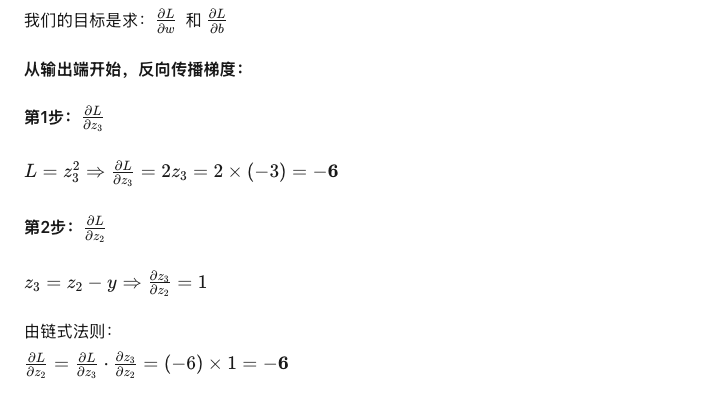

In [6]:
Image(filename='./b1.png')

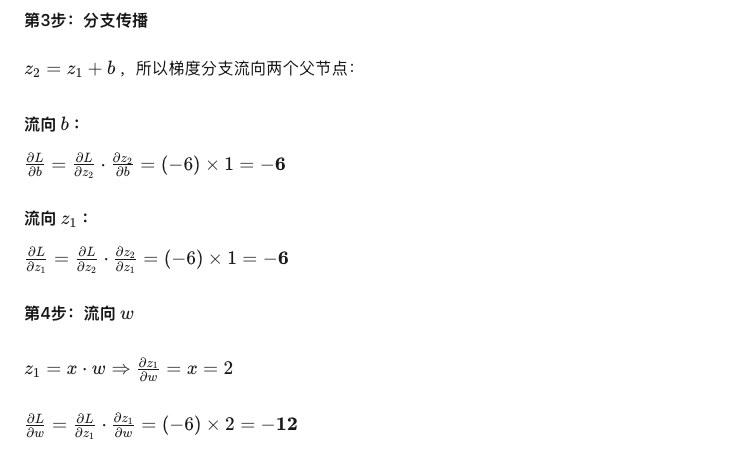

In [7]:
Image(filename='./b2.png')

In [ ]:
正向:  x=2 ──→ [×w=3] ──→ z1=6 ──→ [+b=1] ──→ z2=7 ──→ [-y=10] ──→ z3=-3 ──→ [²] ──→ L=9
                    ↑                                              ↑
反向:  ∂L/∂w=-12 ←── [-6×2]    ∂L/∂b=-6 ←────────────────────── [-6×1]
       (链式)        (局部)      (直接得到)                       (来自上游)
       
       ↑__________ -6 __________↑
              (梯度流动)

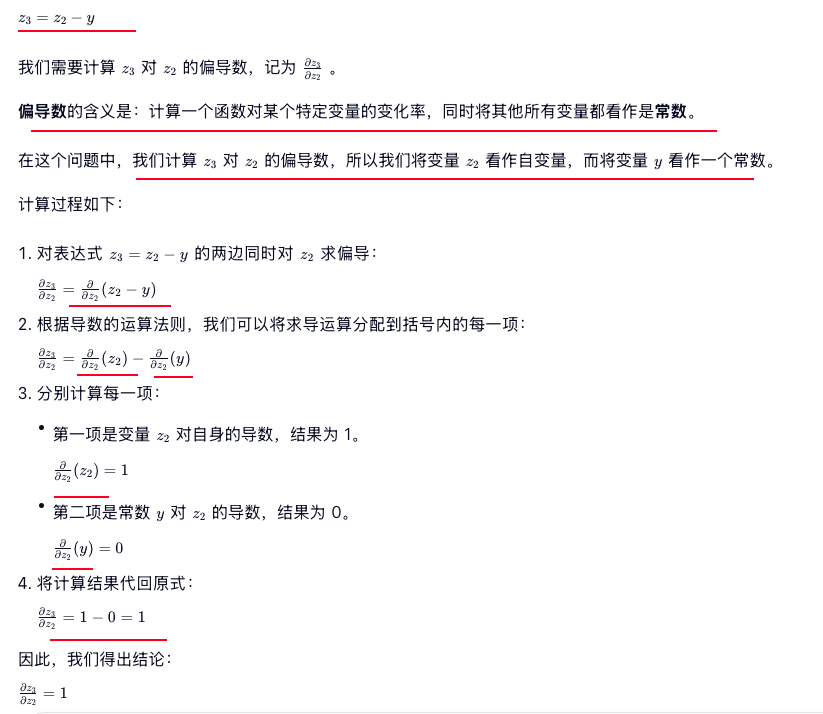

In [9]:
Image(filename='./1.png')

| 特性        | 说明                                                                                      |
| --------- | --------------------------------------------------------------------------------------- |
| **局部计算**  | 每个节点只需知道局部梯度（如乘法节点知道 $\frac{\partial z}{\partial x}$ 和 $\frac{\partial z}{\partial y}$） |
| **链式法则**  | 上游梯度 × 局部梯度 = 传递给下游的梯度                                                                  |
| **复用中间值** | 正向计算的中间结果（如 $z_1, z_2, z_3$）在反向时复用                                                      |
| **计算效率**  | 复杂度 $O(n)$，与网络规模线性相关，远快于数值微分                                                            |


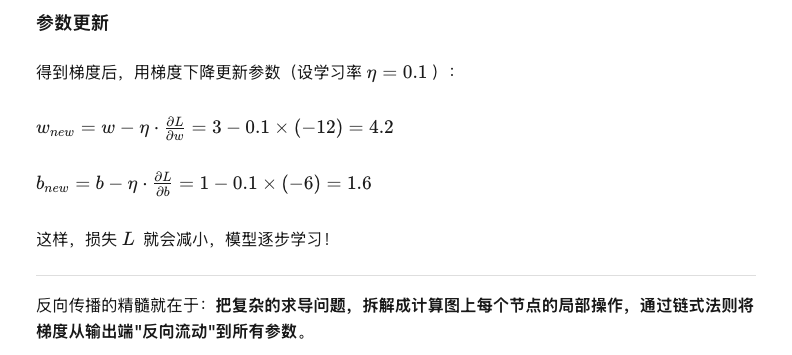

In [8]:
Image(filename='./update.png')

 - w : 3 --> 4.2
 
 - b : 1 -->1.6

# 🚫 错误演示：修改叶节点的后果
## 梯度计算错误

In [10]:
def gradient_error_demo():
    """
    演示修改叶节点导致的梯度错误
    """
    print("=== 梯度计算错误演示 ===\n")
    
    # 正确的方式
    print("1. 正确方式（不修改叶节点）:")
    x1 = torch.tensor([2.0], requires_grad=True)
    y1 = x1 ** 2
    y1.backward()
    print(f"   x={x1.item()}, 梯度={x1.grad.item()}")  # 正确: 4
    
    # 错误的方式（通过非标准方式修改）
    print("\n2. 错误方式（修改叶节点）:")
    x2 = torch.tensor([2.0], requires_grad=True)
    y2 = x2 ** 2
    
    # 通过非标准方式修改（演示目的）
    x2.data = torch.tensor([3.0])  # 修改叶节点
    
    print(f"  修改前 x={2.0}, 修改后 x={x2.item()}")
    
    try:
        y2.backward()  # 尝试反向传播
        print(f"  梯度={x2.grad.item()}")  # 可能得到错误的值
    except RuntimeError as e:
        print(f"  错误: {e}")

gradient_error_demo()

=== 梯度计算错误演示 ===

1. 正确方式（不修改叶节点）:
   x=2.0, 梯度=4.0

2. 错误方式（修改叶节点）:
  修改前 x=2.0, 修改后 x=3.0
  梯度=6.0


## 计算图不一致


In [11]:
def graph_inconsistency_demo():
    """
    演示计算图不一致的问题
    """
    print("=== 计算图不一致演示 ===\n")
    
    # 创建计算图
    x = torch.tensor([2.0], requires_grad=True)
    y = x ** 2
    z = y + 1
    
    print("原始计算图状态:")
    print(f"  x = {x.item()}")
    print(f"  y = {y.item()} (从 x 计算)")
    print(f"  z = {z.item()} (从 y 计算)")
    
    # 记录梯度函数
    print(f"\n梯度函数链:")
    print(f"  z.grad_fn: {z.grad_fn}")  # AddBackward0
    print(f"  y.grad_fn: {y.grad_fn}")  # PowBackward0
    
    # 修改叶节点
    print("\n⚠️ 修改叶节点 x:")
    x.data = torch.tensor([3.0])
    print(f"  x 的新值: {x.item()}")
    print(f"  y 的值: {y.item()}")  # y 仍然是 4，但应该是 9！
    print(f"  z 的值: {z.item()}")  # z 仍然是 5，但应该是 10！
    
    print("\n问题:")
    print("  • y 和 z 的值与计算图不一致")
    print("  • 梯度计算时会使用错误的值")
    print("  • 导致训练不稳定或错误")

graph_inconsistency_demo()

=== 计算图不一致演示 ===

原始计算图状态:
  x = 2.0
  y = 4.0 (从 x 计算)
  z = 5.0 (从 y 计算)

梯度函数链:
  z.grad_fn: <AddBackward0 object at 0x2d5a70160>
  y.grad_fn: <PowBackward0 object at 0x2d5a70160>

⚠️ 修改叶节点 x:
  x 的新值: 3.0
  y 的值: 4.0
  z 的值: 5.0

问题:
  • y 和 z 的值与计算图不一致
  • 梯度计算时会使用错误的值
  • 导致训练不稳定或错误


# ✅ 正确的修改方式
## 使用 param.data

In [12]:
def correct_data_method():
    """
    使用 param.data 正确修改
    """
    print("=== 使用 param.data 正确修改 ===\n")
    
    # 创建参数
    param = nn.Parameter(torch.tensor([2.0]))
    
    print("初始状态:")
    print(f"  param = {param.item()}")
    print(f"  param.requires_grad = {param.requires_grad}")
    print(f"  param.is_leaf = {param.is_leaf}")
    
    # 通过 data 修改
    param.data = torch.tensor([3.0])
    
    print("\n通过 param.data 修改后:")
    print(f"  param = {param.item()}")
    print(f"  param.requires_grad = {param.requires_grad}")  # 保持不变
    print(f"  param.is_leaf = {param.is_leaf}")  # 仍然是叶节点
    
    # 梯度计算正常工作
    loss = param ** 2
    loss.backward()
    print(f"\n梯度计算: {param.grad.item()}")  # 正确: 6

correct_data_method()

=== 使用 param.data 正确修改 ===

初始状态:
  param = 2.0
  param.requires_grad = True
  param.is_leaf = True

通过 param.data 修改后:
  param = 3.0
  param.requires_grad = True
  param.is_leaf = True

梯度计算: 6.0


## 使用 torch.no_grad()

In [13]:
def correct_no_grad_method():
    """
    使用 torch.no_grad() 正确修改
    """
    print("=== 使用 torch.no_grad() 正确修改 ===\n")
    
    param = nn.Parameter(torch.tensor([2.0]))
    
    print("初始状态:")
    print(f"  param = {param.item()}")
    
    # 在 no_grad 上下文中修改
    with torch.no_grad():
        param[0] = 3.0 # 此操作不会记录到计算图中，也不会计算梯度
    
    print("\n修改后:")
    print(f"  param = {param.item()}")
    print(f"  param.requires_grad = {param.requires_grad}")  # 仍然是 True
    
    # 梯度计算
    loss = param ** 2
    loss.backward()
    print(f"  param.grad = {param.grad.item()}")  # 正确: 6

correct_no_grad_method()

=== 使用 torch.no_grad() 正确修改 ===

初始状态:
  param = 2.0

修改后:
  param = 3.0
  param.requires_grad = True
  param.grad = 6.0


## 使用 copy_() 方法

In [14]:
def correct_copy_method():
    """
    使用 copy_() 正确修改
    """
    print("=== 使用 copy_() 正确修改 ===\n")
    
    param = nn.Parameter(torch.tensor([2.0]))
    
    print("初始状态:")
    print(f"  param = {param.item()}")
    
    # 使用 copy_ 复制新值
    new_value = torch.tensor([3.0])
    param.data.copy_(new_value)
    
    print("\n修改后:")
    print(f"  param = {param.item()}")
    print(f"  param.requires_grad = {param.requires_grad}")
    
    # 梯度计算
    loss = param ** 2
    loss.backward()
    print(f"  param.grad = {param.grad.item()}")  # 正确: 6

correct_copy_method()

=== 使用 copy_() 正确修改 ===

初始状态:
  param = 2.0

修改后:
  param = 3.0
  param.requires_grad = True
  param.grad = 6.0


# 实际应用场景
## 场景1：梯度裁剪的正确实现

In [15]:
def gradient_clipping_correct():
    """
    梯度裁剪的正确实现
    """
    print("=== 梯度裁剪正确实现 ===\n")
    
    class CorrectGradientClipping:
        @staticmethod
        def clip_grad_norm_(parameters, max_norm):
            """正确的梯度裁剪实现"""
            total_norm = 0
            for param in parameters:
                if param.grad is not None:
                    # ✅ 正确：使用 grad.data
                    param_norm = param.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            
            total_norm = total_norm ** 0.5
            if total_norm > max_norm:
                clip_coef = max_norm / (total_norm + 1e-6)
                for param in parameters:
                    if param.grad is not None:
                        # ✅ 正确：修改 grad.data
                        param.grad.data.mul_(clip_coef)
            
            return total_norm
    
    # 演示
    model = nn.Linear(10, 5)
    x = torch.randn(32, 10)
    y = torch.randn(32, 5)
    
    output = model(x)
    loss = nn.MSELoss()(output, y)
    loss.backward()
    
    # 梯度裁剪
    norm_before = 0
    for param in model.parameters():
        if param.grad is not None:
            norm_before += param.grad.data.norm().item() ** 2
    norm_before = norm_before ** 0.5
    
    CorrectGradientClipping.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    norm_after = 0
    for param in model.parameters():
        if param.grad is not None:
            norm_after += param.grad.data.norm().item() ** 2
    norm_after = norm_after ** 0.5
    
    print(f"裁剪前梯度范数: {norm_before:.4f}")
    print(f"裁剪后梯度范数: {norm_after:.4f}")

gradient_clipping_correct()

=== 梯度裁剪正确实现 ===

裁剪前梯度范数: 0.8972
裁剪后梯度范数: 0.8972


## 场景2：EMA的正确实现

In [16]:
def ema_correct_implementation():
    """
    EMA的正确实现
    """
    print("=== EMA正确实现 ===\n")
    
    class CorrectEMA:
        def __init__(self, model, decay=0.999):
            self.model = model
            self.decay = decay
            # ✅ 正确：克隆 data
            self.shadow = [param.data.clone() for param in model.parameters()]
        
        def update(self):
            """更新影子参数"""
            with torch.no_grad():  # ✅ 使用 no_grad
                for shadow, param in zip(self.shadow, self.model.parameters()):
                    # ✅ 正确：直接操作 data
                    shadow.mul_(self.decay).add_(param.data, alpha=1 - self.decay)
        
        def apply_shadow(self):
            """应用影子参数"""
            with torch.no_grad():
                for shadow, param in zip(self.shadow, self.model.parameters()):
                    # ✅ 正确：使用 copy_
                    param.data.copy_(shadow)
    
    # 演示
    model = nn.Linear(10, 5)
    ema = CorrectEMA(model, decay=0.99)
    
    print("初始参数:")
    print(f"  原始: {model.weight.data[0, :3]}")
    print(f"  影子: {ema.shadow[0][0, :3]}")
    
    # 更新参数
    with torch.no_grad():
        model.weight.data.add_(torch.randn_like(model.weight) * 0.1)
    
    # 更新EMA
    ema.update()
    
    print("\n更新后:")
    print(f"  原始: {model.weight.data[0, :3]}")
    print(f"  影子: {ema.shadow[0][0, :3]}")

ema_correct_implementation()

=== EMA正确实现 ===

初始参数:
  原始: tensor([ 0.1221, -0.1031, -0.2473])
  影子: tensor([ 0.1221, -0.1031, -0.2473])

更新后:
  原始: tensor([ 0.0804,  0.0376, -0.3051])
  影子: tensor([ 0.1217, -0.1017, -0.2479])


# 📊 总结对比

In [17]:
def final_comparison():
    """
    总结对比
    """
    print("=== 叶节点修改方式对比 ===\n")
    
    comparison = {
        "操作": ["param[0]=value", "param.data[0]=value", "with torch.no_grad():", "copy_()"],
        "是否允许": ["❌ 禁止", "✅ 允许", "✅ 允许", "✅ 允许"],
        "梯度完整性": ["破坏", "保持", "保持", "保持"],
        "计算图": ["破坏", "保持", "保持", "保持"],
        "推荐度": ["不推荐", "强烈推荐", "推荐", "推荐"]
    }
    
    # 打印表格
    print(f"{'操作':<25} {'是否允许':<12} {'梯度完整性':<12} {'计算图':<12} {'推荐度':<12}")
    print("-" * 75)
    for op, allowed, grad, graph, rec in zip(*comparison.values()):
        print(f"{op:<25} {allowed:<12} {grad:<12} {graph:<12} {rec:<12}")

final_comparison()

=== 叶节点修改方式对比 ===

操作                        是否允许         梯度完整性        计算图          推荐度         
---------------------------------------------------------------------------
param[0]=value            ❌ 禁止         破坏           破坏           不推荐         
param.data[0]=value       ✅ 允许         保持           保持           强烈推荐        
with torch.no_grad():     ✅ 允许         保持           保持           推荐          
copy_()                   ✅ 允许         保持           保持           推荐          


为什么禁止直接修改叶节点？
1. 计算图一致性：叶节点的值被记录在计算图中，直接修改会导致前后不一致

2. 梯度计算正确性：反向传播依赖前向传播的中间值，修改会破坏梯度计算

3. 自动微分机制：PyTorch的autograd需要完整的操作历史

4. 数值稳定性：避免训练过程中出现难以调试的错误

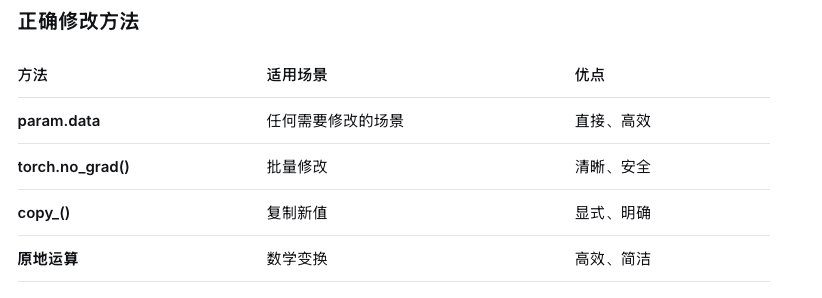

In [18]:
Image(filename='./change_leaf.png')

## 最佳实践

In [ ]:
# ✅ 推荐
param.data = new_value
param.data.mul_(factor)
with torch.no_grad():
    param[:] = new_values

# ❌ 避免
param[0] = value  # 直接赋值
param = new_param  # 改变引用